# New Metabolic Genes — Functional Overview

Parses `new_metabolic_gene_annotation.csv` (308 new genes added to the metabolism module)
to produce:

1. A clean per-gene annotation table with primary function and pathway labels.
2. Top-level and sub-level functional category frequency bar charts.
3. A pathway enrichment summary CSV for downstream use.

Data source: EcoCyc K-12 MultiFun classification, curated by Cyrus Appleby-Maher.

In [1]:
import ast
import re
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

plt.rcParams.update({
	'font.family': 'sans-serif',
	'font.size': 11,
	'axes.spines.top': False,
	'axes.spines.right': False,
})

HERE = Path('.')
CSV_PATH = HERE / 'new_metabolic_gene_annotation.csv'
OUT_DIR = HERE / 'gene_overview_20260518'
OUT_DIR.mkdir(exist_ok=True)

## 1. Load and parse the annotation file

In [2]:
df = pd.read_csv(CSV_PATH)
df.columns = df.columns.str.strip()
print(f"{len(df)} genes loaded")
df.head(3)

307 genes loaded


,Gene ID (EcoCyc),Gene locus ID,Gene name,Enzyme encoded,Pathways,Pathways parent,Protein products,MultiFuntional ID,MultiFuntional name,Reactions,Description by Cyrus
0,EG10022,b4015,aceA,ISOCIT-LYASE,GLYOXYLATE-BYPASS,Energy-Metabolism,ISOCIT-LYASE-MONOMER,BC-1.7.2,['metabolism -> central intermediary metabolis...,['ISOCIT-CLEAV-RXN'],acetate transport + metabolism
1,EG10023,b4014,aceB,MALATE-SYNTHASE,GLYOXYLATE-BYPASS,Energy-Metabolism,MALATE-SYNTHASE,BC-1.7.2,['metabolism -> central intermediary metabolis...,['MALSYN-RXN'],acetate transport + metabolism
2,EG11942,b4067,actP,CPLX0-7955,NaN,NaN,YJCG-MONOMER,"['BC-4.2.A', 'BC-6.1']",['transport -> Electrochemical potential drive...,"['RXN0-1981', 'RXN0-5111', 'TRANS-RXN0-576']",acetate transport + metabolism


In [3]:
def parse_list_column(val):
	"""Parse a stringified Python list or bare string into a list of strings."""
	if pd.isna(val) or str(val).strip() == '':
		return []
	try:
		result = ast.literal_eval(str(val).strip())
		if isinstance(result, list):
			return [str(x).strip() for x in result]
		return [str(result).strip()]
	except Exception:
		return [str(val).strip()]


def extract_levels(path_str):
	"""Split a MultiFun path into (level1, level2, level3) tuple."""
	parts = [p.strip() for p in path_str.split('->')]
	level1 = parts[0] if len(parts) > 0 else 'unclassified'
	level2 = parts[1] if len(parts) > 1 else None
	level3 = parts[2] if len(parts) > 2 else None
	return level1.lower(), level2, level3


df['multifun_paths'] = df['MultiFuntional name'].apply(parse_list_column)

# Derive primary Level1 and Level2 from the first listed MultiFun path.
def primary_level(row, n):
	paths = row['multifun_paths']
	if not paths:
		return 'unclassified'
	levels = extract_levels(paths[0])
	return levels[n - 1] if levels[n - 1] else 'unclassified'


df['primary_level1'] = df.apply(lambda r: primary_level(r, 1), axis=1)
df['primary_level2'] = df.apply(lambda r: primary_level(r, 2), axis=1)

df[['Gene name', 'Gene locus ID', 'primary_level1', 'primary_level2',
	'Description by Cyrus']].head(10)

,Gene name,Gene locus ID,primary_level1,primary_level2,Description by Cyrus
0,aceA,b4015,metabolism,central intermediary metabolism,acetate transport + metabolism
1,aceB,b4014,metabolism,central intermediary metabolism,acetate transport + metabolism
2,actP,b4067,transport,Electrochemical potential driven transporters,acetate transport + metabolism
3,adeP,b3714,transport,Electrochemical potential driven transporters,adenine transport
4,adiC,b4115,transport,Electrochemical potential driven transporters,"transport, acid resistance"
5,aes,b0476,metabolism,carbon utilization,general fatty acid degradation
6,agaS,b3136,metabolism,carbon utilization,"enzyme, only in some strains"
7,agp,b1002,metabolism,central intermediary metabolism,periplasmic phosphatase to import g6p
8,ahpC,b0605,cell processes,protection,general peroxidase
9,allA,b0505,metabolism,central intermediary metabolism,allantoin purine utilization nitrogen source


## 2. Per-gene annotation table

In [4]:
# Flatten all paths (one row per gene-path combination) for enrichment counting.
records = []
for _, row in df.iterrows():
	for path in row['multifun_paths']:
		l1, l2, l3 = extract_levels(path)
		records.append({
			'gene': row['Gene name'],
			'locus_id': row['Gene locus ID'],
			'level1': l1,
			'level2': l2,
			'level3': l3,
			'full_path': path,
		})

flat_df = pd.DataFrame(records)
print(f"{len(flat_df)} total gene-pathway assignments across {flat_df['gene'].nunique()} genes")

# Clean export: per gene with all unique top-level categories
gene_summary = (
	flat_df.groupby('gene')['level1']
	.apply(lambda x: ' | '.join(sorted(x.unique())))
	.reset_index()
	.rename(columns={'level1': 'all_level1_categories'})
)
gene_table = df[[
	'Gene ID (EcoCyc)', 'Gene locus ID', 'Gene name',
	'Enzyme encoded', 'Description by Cyrus',
	'primary_level1', 'primary_level2'
]].merge(gene_summary, left_on='Gene name', right_on='gene', how='left').drop(columns='gene')

gene_table.to_csv(OUT_DIR / 'gene_annotation_table.csv', index=False)
print("Saved gene_annotation_table.csv")
gene_table.head(5)

575 total gene-pathway assignments across 307 genes
Saved gene_annotation_table.csv


,Gene ID (EcoCyc),Gene locus ID,Gene name,Enzyme encoded,Description by Cyrus,primary_level1,primary_level2,all_level1_categories
0,EG10022,b4015,aceA,ISOCIT-LYASE,acetate transport + metabolism,metabolism,central intermediary metabolism,metabolism
1,EG10023,b4014,aceB,MALATE-SYNTHASE,acetate transport + metabolism,metabolism,central intermediary metabolism,metabolism
2,EG11942,b4067,actP,CPLX0-7955,acetate transport + metabolism,transport,Electrochemical potential driven transporters,cell structure | transport
3,EG11724,b3714,adeP,EG11724-MONOMER,adenine transport,transport,Electrochemical potential driven transporters,transport
4,EG12462,b4115,adiC,CPLX0-7535,"transport, acid resistance",transport,Electrochemical potential driven transporters,cell structure | transport


## 3. Level 1 functional category distribution

Each gene is counted once per unique Level 1 category it belongs to.

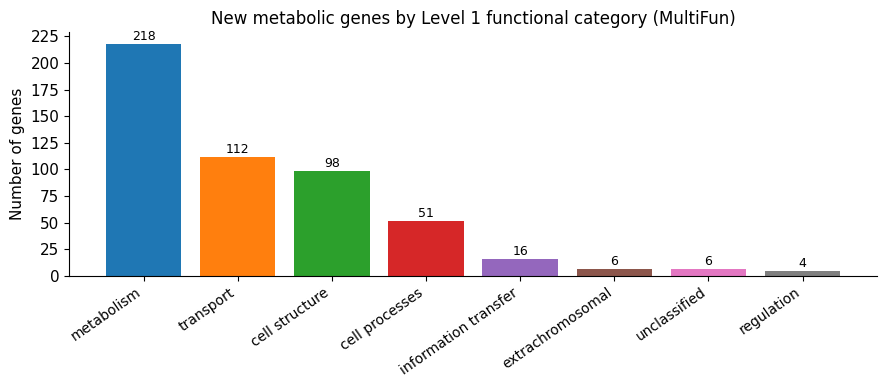

level1
metabolism              218
transport               112
cell structure           98
cell processes           51
information transfer     16
extrachromosomal          6
unclassified              6
regulation                4


In [5]:
# Count unique genes per Level 1 category.
l1_gene_counts = (
	flat_df.drop_duplicates(subset=['gene', 'level1'])
	.groupby('level1')['gene']
	.count()
	.sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(9, 4))
colors = plt.cm.tab10.colors
bars = ax.bar(
	range(len(l1_gene_counts)),
	l1_gene_counts.values,
	color=[colors[i % len(colors)] for i in range(len(l1_gene_counts))],
	edgecolor='none',
)
ax.set_xticks(range(len(l1_gene_counts)))
ax.set_xticklabels(l1_gene_counts.index, rotation=35, ha='right', fontsize=10)
ax.set_ylabel('Number of genes')
ax.set_title('New metabolic genes by Level 1 functional category (MultiFun)', fontsize=12)
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
for bar in bars:
	height = bar.get_height()
	ax.text(bar.get_x() + bar.get_width() / 2, height + 1, str(height),
		ha='center', va='bottom', fontsize=9)
fig.tight_layout()
fig.savefig(OUT_DIR / 'level1_category_distribution.svg', dpi=150)
plt.show()
print(l1_gene_counts.to_string())

## 4. Level 2 breakdown within 'metabolism'

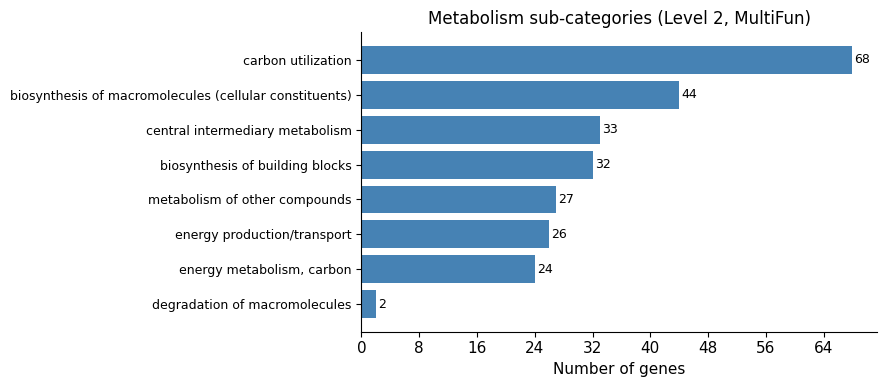

In [6]:
met_l2 = (
	flat_df[flat_df['level1'] == 'metabolism']
	.drop_duplicates(subset=['gene', 'level2'])
	.groupby('level2')['gene']
	.count()
	.sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(9, max(4, len(met_l2) * 0.45)))
ax.barh(
	range(len(met_l2)),
	met_l2.values,
	color='steelblue',
	edgecolor='none',
)
ax.set_yticks(range(len(met_l2)))
ax.set_yticklabels(met_l2.index, fontsize=9)
ax.set_xlabel('Number of genes')
ax.set_title('Metabolism sub-categories (Level 2, MultiFun)', fontsize=12)
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
for i, v in enumerate(met_l2.values):
	ax.text(v + 0.3, i, str(v), va='center', fontsize=9)
fig.tight_layout()
fig.savefig(OUT_DIR / 'metabolism_level2_distribution.svg', dpi=150)
plt.show()

## 5. Level 2 breakdown within 'transport'

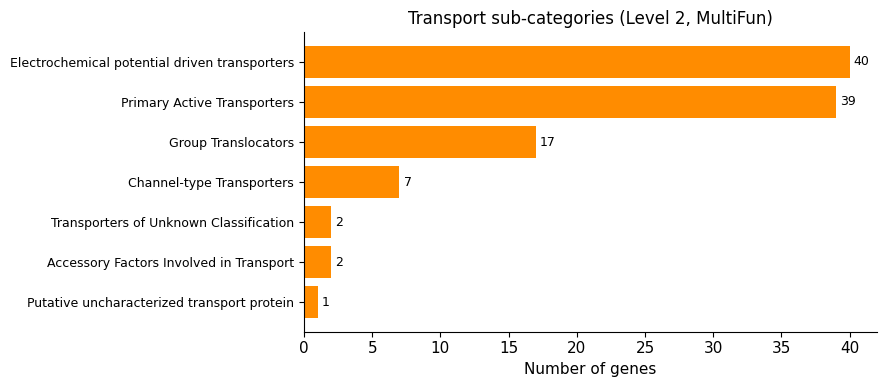

In [7]:
trans_l2 = (
	flat_df[flat_df['level1'] == 'transport']
	.drop_duplicates(subset=['gene', 'level2'])
	.groupby('level2')['gene']
	.count()
	.sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(9, max(4, len(trans_l2) * 0.55)))
ax.barh(
	range(len(trans_l2)),
	trans_l2.values,
	color='darkorange',
	edgecolor='none',
)
ax.set_yticks(range(len(trans_l2)))
ax.set_yticklabels(trans_l2.index, fontsize=9)
ax.set_xlabel('Number of genes')
ax.set_title('Transport sub-categories (Level 2, MultiFun)', fontsize=12)
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
for i, v in enumerate(trans_l2.values):
	ax.text(v + 0.3, i, str(v), va='center', fontsize=9)
fig.tight_layout()
fig.savefig(OUT_DIR / 'transport_level2_distribution.svg', dpi=150)
plt.show()

## 6. Top 20 specific pathways (Level 3) across all genes

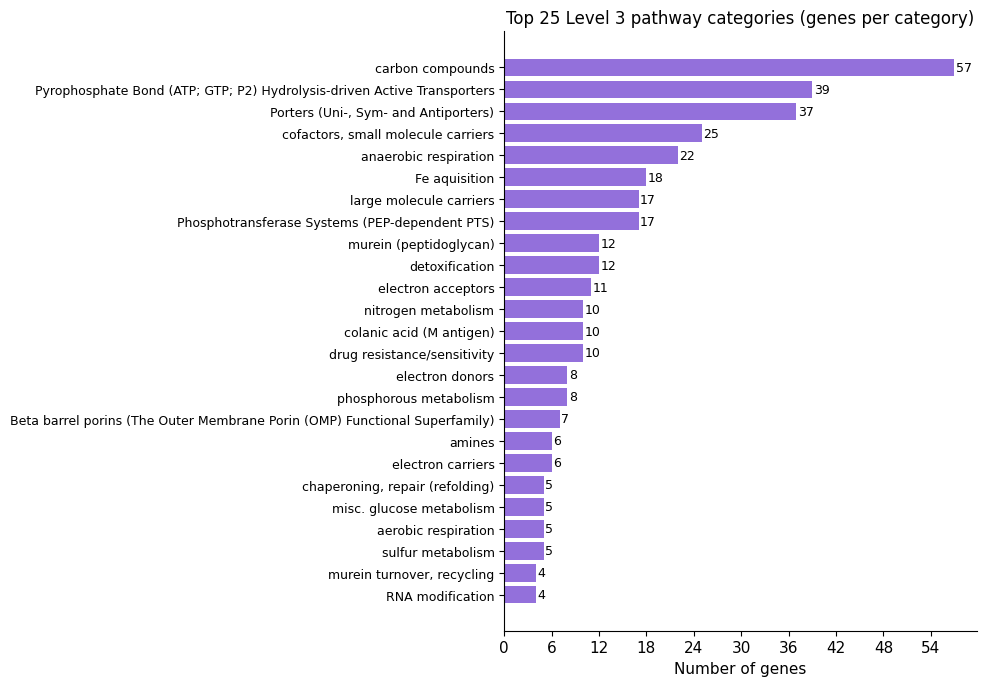

In [8]:
l3_counts = (
	flat_df.dropna(subset=['level3'])
	.drop_duplicates(subset=['gene', 'level3'])
	.groupby('level3')['gene']
	.count()
	.sort_values(ascending=False)
	.head(25)
)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(
	range(len(l3_counts)),
	l3_counts.values[::-1],
	color='mediumpurple',
	edgecolor='none',
)
ax.set_yticks(range(len(l3_counts)))
ax.set_yticklabels(l3_counts.index[::-1], fontsize=9)
ax.set_xlabel('Number of genes')
ax.set_title('Top 25 Level 3 pathway categories (genes per category)', fontsize=12)
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
for i, v in enumerate(l3_counts.values[::-1]):
	ax.text(v + 0.2, i, str(v), va='center', fontsize=9)
fig.tight_layout()
fig.savefig(OUT_DIR / 'top25_level3_pathways.svg', dpi=150)
plt.show()

## 7. Functional category breakdown of the Cyrus descriptions

Group genes by their hand-curated `Description by Cyrus` to see which
biological themes are most represented.

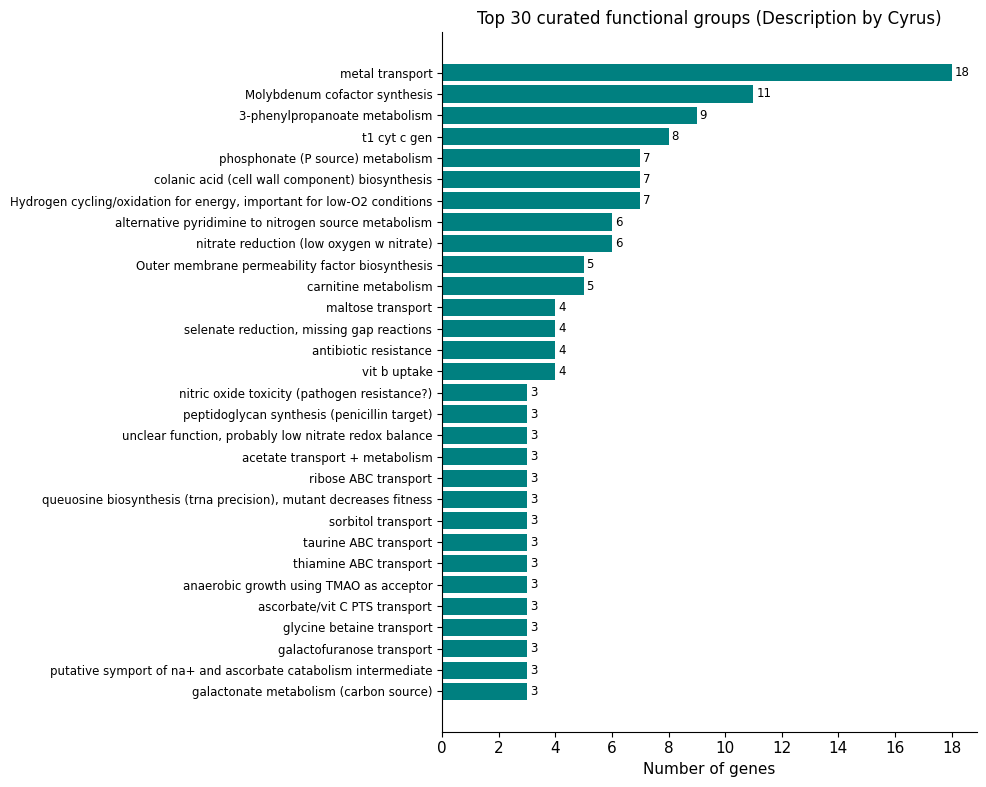

In [9]:
desc_counts = (
	df['Description by Cyrus']
	.str.strip()
	.value_counts()
	.head(30)
)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(
	range(len(desc_counts)),
	desc_counts.values[::-1],
	color='teal',
	edgecolor='none',
)
ax.set_yticks(range(len(desc_counts)))
ax.set_yticklabels(desc_counts.index[::-1], fontsize=8.5)
ax.set_xlabel('Number of genes')
ax.set_title('Top 30 curated functional groups (Description by Cyrus)', fontsize=12)
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
for i, v in enumerate(desc_counts.values[::-1]):
	ax.text(v + 0.1, i, str(v), va='center', fontsize=8.5)
fig.tight_layout()
fig.savefig(OUT_DIR / 'top30_cyrus_descriptions.svg', dpi=150)
plt.show()

## 8. Save pathway enrichment summary

In [10]:
# Level 1 enrichment
l1_enrichment = (
	flat_df.drop_duplicates(subset=['gene', 'level1'])
	.groupby('level1')['gene']
	.count()
	.reset_index()
	.rename(columns={'gene': 'gene_count'})
	.assign(pct=lambda x: (x['gene_count'] / len(df) * 100).round(1))
	.sort_values('gene_count', ascending=False)
)

# Level 2 enrichment (all categories)
l2_enrichment = (
	flat_df.dropna(subset=['level2'])
	.drop_duplicates(subset=['gene', 'level2'])
	.groupby(['level1', 'level2'])['gene']
	.count()
	.reset_index()
	.rename(columns={'gene': 'gene_count'})
	.sort_values(['level1', 'gene_count'], ascending=[True, False])
)

l1_enrichment.to_csv(OUT_DIR / 'level1_enrichment.csv', index=False)
l2_enrichment.to_csv(OUT_DIR / 'level2_enrichment.csv', index=False)
print("Saved enrichment CSVs")

print("\n=== Level 1 Enrichment ===")
print(l1_enrichment.to_string(index=False))
print("\n=== Level 2 Enrichment (top 20) ===")
print(l2_enrichment.head(20).to_string(index=False))

Saved enrichment CSVs

=== Level 1 Enrichment ===
              level1  gene_count  pct
          metabolism         218 71.0
           transport         112 36.5
      cell structure          98 31.9
      cell processes          51 16.6
information transfer          16  5.2
    extrachromosomal           6  2.0
        unclassified           6  2.0
          regulation           4  1.3

=== Level 2 Enrichment (top 20) ===
              level1                                                        level2  gene_count
      cell processes                                                   adaptations          26
      cell processes                                                    protection          24
      cell processes                                                 cell division           5
      cell processes motility, chemotaxis, energytaxis (aerotaxis, redoxtaxis etc)           2
      cell structure                                                      membrane          81
 

## 9. Stacked bar: metabolism sub-categories by Level 3 cofactor/pathway

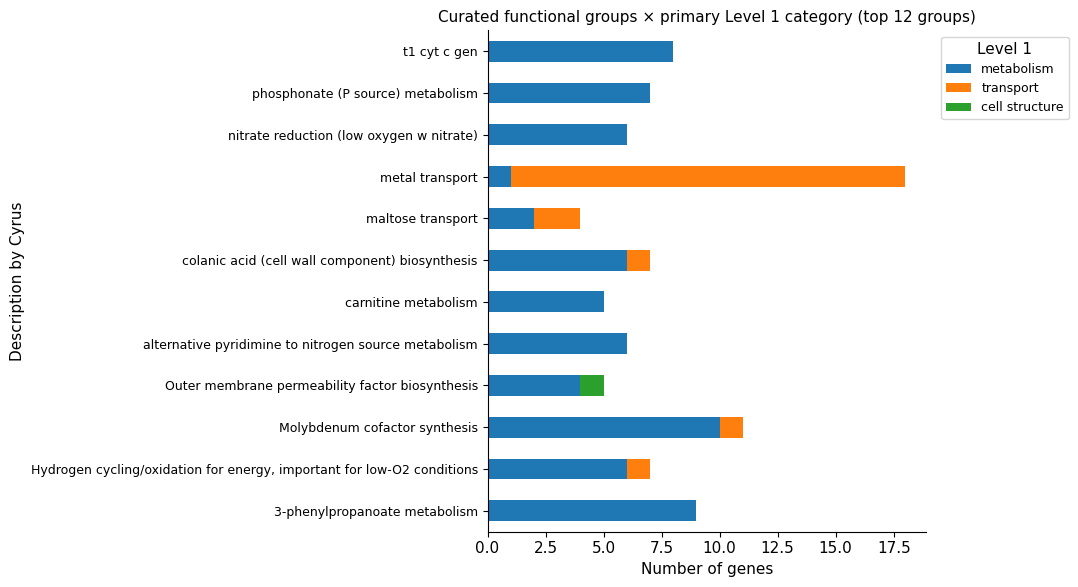

In [11]:
# Annotate each gene with its primary 'Description by Cyrus' cluster.
desc_level = (
	df[['Gene name', 'primary_level1', 'Description by Cyrus']]
	.dropna(subset=['Description by Cyrus'])
)

# Top 10 descriptions × top 6 Level1 categories
top_descs = desc_level['Description by Cyrus'].value_counts().head(12).index
filtered = desc_level[desc_level['Description by Cyrus'].isin(top_descs)]

pivot = (
	filtered.groupby(['Description by Cyrus', 'primary_level1'])['Gene name']
	.count()
	.unstack(fill_value=0)
)

# Keep only the top 5 Level1 categories in this view.
top_l1_cols = pivot.sum().sort_values(ascending=False).head(5).index
pivot = pivot[top_l1_cols]

fig, ax = plt.subplots(figsize=(11, 6))
pivot.plot(kind='barh', stacked=True, ax=ax, edgecolor='none')
ax.set_xlabel('Number of genes')
ax.set_title(
	'Curated functional groups × primary Level 1 category (top 12 groups)',
	fontsize=11
)
ax.legend(title='Level 1', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
ax.tick_params(axis='y', labelsize=9)
fig.tight_layout()
fig.savefig(OUT_DIR / 'desc_by_level1_stacked.svg', dpi=150)
plt.show()

In [12]:
print("All outputs saved to:", OUT_DIR.resolve())

All outputs saved to: /Users/heenasaqib/dev/vEcoli/notebooks/Heena notebooks/Metabolism_New Genes/gene_overview_20260518
